# Biển số – Pipeline OCR (OpenCV + Tesseract)
Notebook này chứa các bước tiền xử lý ảnh biển số và thử nhiều cấu hình OCR để đọc số.

In [7]:
# Cell 1 – Setup & environment checks
import os, shutil, sys, math, json, textwrap
from pathlib import Path
import cv2, numpy as np, matplotlib.pyplot as plt

try:
    import pytesseract
    TESS_PATH = shutil.which("tesseract")
    TESS_AVAILABLE = TESS_PATH is not None
except Exception:
    pytesseract = None
    TESS_AVAILABLE = False

print("OpenCV:", cv2.__version__)
print("Tesseract wrapper:", "available" if pytesseract else "not importable")
print("Tesseract binary:", TESS_PATH if TESS_AVAILABLE else "NOT FOUND")

OpenCV: 4.12.0
Tesseract wrapper: available
Tesseract binary: /usr/bin/tesseract


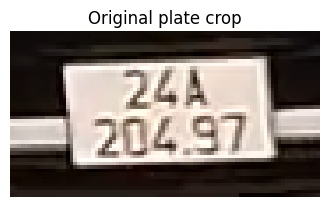

Image shape: (47, 88, 3)


In [8]:
# Cell 2 – Load image
from pathlib import Path
import cv2, matplotlib.pyplot as plt

IMG_PATH = Path("image/image copy 3.png")  # đổi nếu cần
img_bgr = cv2.imread(str(IMG_PATH))
assert img_bgr is not None, f"Image not found: {IMG_PATH}"
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,3)); plt.imshow(img_rgb); plt.axis("off"); plt.title("Original plate crop"); plt.show()
print("Image shape:", img_rgb.shape)

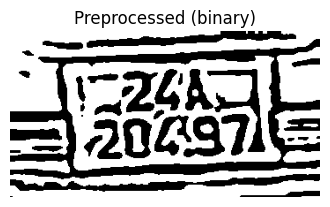

In [9]:
# Cell 3 – Preprocessing helpers
import cv2, numpy as np

def upscale(img, scale=4):
    return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

def to_gray(img): return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def clahe_enhance(gray, clip=3.0, tile=8):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return clahe.apply(gray)

def unsharp_mask(gray, ksize=3, amount=1.0):
    blur = cv2.GaussianBlur(gray, (ksize, ksize), 0)
    us = cv2.addWeighted(gray, 1 + amount, blur, -amount, 0)
    return np.clip(us, 0, 255).astype(np.uint8)

def binarize(gray):
    try:
        import cv2.ximgproc as xip
        sau = xip.niBlackThreshold(gray, 255, cv2.THRESH_BINARY, 25, -0.2, binarizationMethod=xip.BINARIZATION_SAUVOLA)
        return sau
    except Exception:
        ad = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 31, 5)
        return ad

def morph_refine(bin_img):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    opened = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel, iterations=1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)
    return closed

def preprocess_pipeline(img_rgb):
    up = upscale(img_rgb, 4)
    gray = to_gray(up)
    cla = clahe_enhance(gray, 3.0, 8)
    den = cv2.bilateralFilter(cla, d=7, sigmaColor=50, sigmaSpace=50)
    shp = unsharp_mask(den, 3, 1.0)
    bi = morph_refine(binarize(shp))
    return {"upscaled": up, "gray": gray, "clahe": cla, "denoise": den, "sharpen": shp, "binary": bi}

variants = preprocess_pipeline(img_rgb)
plt.figure(figsize=(4,3)); plt.imshow(variants["binary"], cmap="gray"); plt.axis("off"); plt.title("Preprocessed (binary)"); plt.show()

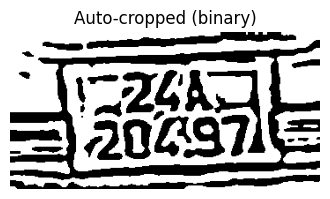

In [10]:
# Cell 4 – Optional: auto-trim plate region
import numpy as np, cv2, matplotlib.pyplot as plt

def auto_crop_to_plate(binary_img, margin=10):
    inv = cv2.bitwise_not(binary_img)
    contours, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return binary_img
    c = max(contours, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)
    h0, w0 = binary_img.shape[:2]
    x0 = max(0, x - margin); y0 = max(0, y - margin)
    x1 = min(w0, x + w + margin); y1 = min(h0, y + h + margin)
    return binary_img[y0:y1, x0:x1]

tight = auto_crop_to_plate(variants["binary"], 10)
plt.figure(figsize=(4,3)); plt.imshow(tight, cmap="gray"); plt.axis("off"); plt.title("Auto-cropped (binary)"); plt.show()

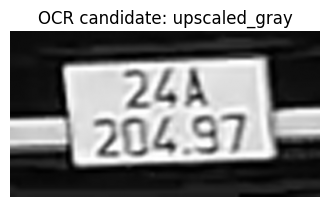

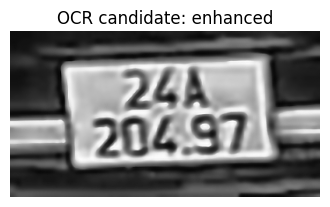

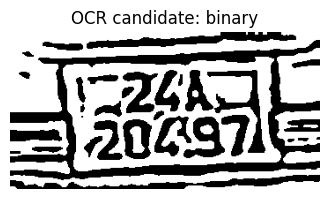

Prepared 3 candidates.


In [11]:
# Cell 5 – Build OCR candidates
candidates = {
    "upscaled_gray": variants["gray"],
    "enhanced": variants["sharpen"],
    "binary": tight
}

for name, im in candidates.items():
    import matplotlib.pyplot as plt
    plt.figure(figsize=(4,3))
    if len(im.shape)==2: plt.imshow(im, cmap="gray")
    else: plt.imshow(im)
    plt.axis("off"); plt.title(f"OCR candidate: {name}"); plt.show()

print("Prepared", len(candidates), "candidates.")

In [13]:
# Cell 6 – OCR runner (Tesseract)
import re, json, numpy as np, cv2
if pytesseract is None or not shutil.which("tesseract"):
    print("Tesseract not found – please install Tesseract OCR to run this cell.")
else:
    def ocr_configs():
        base = ["--oem 1 --psm 4", "--oem 1 --psm 6", "--oem 1 --psm 7", "--oem 1 --psm 11", "--oem 1 --psm 13"]
        return [b + " -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789." for b in base]

    def clean(s):
        s = s.strip().upper()
        s = re.sub(r"[^A-Z0-9.]", "", s)
        s = s.replace("O","0").replace("I","1")
        return s

    results = []
    for nm, im in candidates.items():
        im3 = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB) if len(im.shape)==2 else im
        for cfg in ocr_configs():
            txt = clean(pytesseract.image_to_string(im3, config=cfg))
            data = pytesseract.image_to_data(im3, config=cfg, output_type=pytesseract.Output.DICT)
            confs = [float(c) for c in data.get("conf", []) if str(c) not in ("-1","--")]
            conf = float(np.mean(confs)) if confs else 0.0
            results.append({"img": nm, "cfg": cfg, "text": txt, "avg_conf": round(conf,2)})
    results = sorted(results, key=lambda r: (r["avg_conf"], len(r["text"])), reverse=True)[:10]
    print(json.dumps(results, indent=2))

[
  {
    "img": "binary",
    "cfg": "--oem 1 --psm 4 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.",
    "text": "",
    "avg_conf": 95.0
  },
  {
    "img": "enhanced",
    "cfg": "--oem 1 --psm 13 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.",
    "text": "EE",
    "avg_conf": 2.0
  },
  {
    "img": "binary",
    "cfg": "--oem 1 --psm 11 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.",
    "text": "V2GKANASTY",
    "avg_conf": 0.0
  },
  {
    "img": "enhanced",
    "cfg": "--oem 1 --psm 11 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.",
    "text": "75",
    "avg_conf": 0.0
  },
  {
    "img": "binary",
    "cfg": "--oem 1 --psm 13 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.",
    "text": "PS",
    "avg_conf": 0.0
  },
  {
    "img": "upscaled_gray",
    "cfg": "--oem 1 --psm 6 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.",
    "text": "E",
    "avg_conf": 0.0
  },

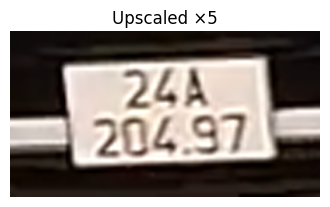

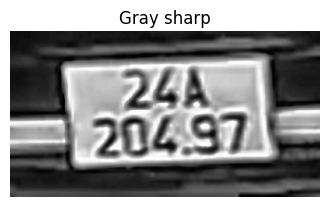

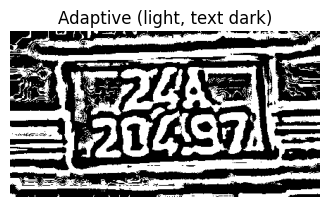

Layout: one-line | y_split: None


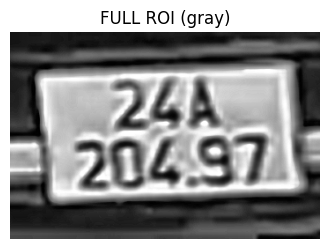

Top line: 265
Bottom line: 2657
Plate: 265 2657


In [61]:
# ====== Tesseract-friendly: ưu tiên GRAY + chọn theo confidence ======
from pathlib import Path
import cv2, numpy as np, pytesseract, re
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_PATH = Path("image/image copy 3.png")  # ⬅️ sửa đường dẫn nếu cần
assert IMAGE_PATH.exists(), f"Không thấy ảnh: {IMAGE_PATH}"

def show(title, img, gray=False, size=(4,3)):
    plt.figure(figsize=size)
    if gray: plt.imshow(img, cmap="gray")
    else:    plt.imshow(img)
    plt.title(title); plt.axis("off"); plt.show()

# 1) Load & upscale (vừa đủ, không quá tay)
bgr = cv2.imread(str(IMAGE_PATH))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
up  = cv2.resize(rgb, None, fx=5, fy=5, interpolation=cv2.INTER_CUBIC)
show("Upscaled ×5", up)

# 2) Ảnh xám + tăng tương phản + sharpen nhẹ (Tesseract thích dạng này)
gray   = cv2.cvtColor(up, cv2.COLOR_RGB2GRAY)
clahe  = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8)).apply(gray)
sharp  = cv2.addWeighted(clahe, 1.6, cv2.GaussianBlur(clahe,(3,3),0), -0.6, 0)

# 3) Adaptive “nhẹ” làm biến thể (không dùng nhị phân cứng)
bin_soft = cv2.adaptiveThreshold(
    sharp, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 25, 2
)
# Tesseract thích chữ tối trên nền sáng → nếu cần đảo
if np.mean(bin_soft) < 127: bin_soft = 255 - bin_soft

show("Gray sharp", sharp, True)
show("Adaptive (light, text dark)", 255 - bin_soft, True)

# 4) Phát hiện 1 dòng / 2 dòng bằng horizontal projection (trên GRAY)
def detect_layout(gray_img):
    H, W = gray_img.shape
    # dùng Sobel-Y để nhấn mạnh các hàng chữ, rồi lấy tổng theo hàng
    sob = cv2.Sobel(gray_img, cv2.CV_32F, 0, 1, ksize=3)
    rowsum = np.abs(sob).sum(axis=1).astype(np.float32)
    rowsum = cv2.blur(rowsum.reshape(-1,1), (51,1)).ravel()
    p = rowsum.argsort()[-2:][::-1]
    p = np.sort(p)
    if len(p)==2 and abs(int(p[1])-int(p[0])) > 0.18*H:
        lo, hi = int(p[0]), int(p[1])
        valley = lo + int(np.argmin(rowsum[lo:hi]))
        return "two-lines", valley
    return "one-line", None

layout, y_split = detect_layout(sharp)
print("Layout:", layout, "| y_split:", y_split)

# 5) Tạo ROI theo layout (cắt bỏ viền 10% hai bên để tránh mép khung)
H, W = sharp.shape
x0, x1 = int(0.10*W), int(0.90*W)
def make_rois(gray_img, bin_img):
    if layout == "two-lines":
        pad = int(0.02*H)
        top_g = gray_img[0: max(0,int(y_split)+pad), x0:x1]
        bot_g = gray_img[max(0,int(y_split)-pad): H, x0:x1]
        top_b = bin_img[0: max(0,int(y_split)+pad), x0:x1]
        bot_b = bin_img[max(0,int(y_split)-pad): H, x0:x1]
        return (top_g, bot_g), (top_b, bot_b)
    else:
        full_g = gray_img[:, x0:x1]
        full_b = bin_img[:, x0:x1]
        return (full_g, None), (full_b, None)

(gray_top, gray_bot), (bin_top, bin_bot) = make_rois(sharp, bin_soft)

if layout == "two-lines":
    show("TOP ROI (gray)", gray_top, True, (4,2.2))
    show("BOTTOM ROI (gray)", gray_bot, True, (4,2.2))
else:
    show("FULL ROI (gray)", gray_top, True)

# 6) OCR helper: thử nhiều biến thể × PSM, chọn theo avg confidence
def ocr_best(gray_img, bin_img, whitelist, psm_list=(7,6,13), numeric=False):
    variants = []
    # a) gray sharpened
    variants.append(gray_img)
    # b) equalized
    eq = cv2.equalizeHist(gray_img)
    variants.append(eq)
    # c) soft-binary (đảo để text đậm)
    if bin_img is not None:
        v = 255 - bin_img
        variants.append(v)

    best = {"text":"", "conf":-1.0, "src":""}
    for idx, v in enumerate(variants):
        img_rgb = cv2.cvtColor(v, cv2.COLOR_GRAY2RGB)
        for psm in psm_list:
            cfg = f"--oem 1 --psm {psm} -c tessedit_char_whitelist={whitelist}"
            if numeric: cfg += " -c classify_bln_numeric_mode=1"
            txt = pytesseract.image_to_string(Image.fromarray(img_rgb), config=cfg).strip().upper()
            txt = re.sub(r"[^A-Z0-9.]", "", txt)
            data = pytesseract.image_to_data(Image.fromarray(img_rgb), config=cfg, output_type=pytesseract.Output.DICT)
            confs = [float(c) for c in data.get("conf", []) if str(c).replace('.','',1).isdigit()]
            avg = float(np.mean(confs)) if confs else 0.0
            if avg > best["conf"] or (avg==best["conf"] and len(txt)>len(best["text"])):
                best = {"text": txt, "conf": avg, "src": f"var{idx+1}/psm{psm}"}
    return best

# 7) Chạy OCR theo layout
if layout == "two-lines":
    top_res = ocr_best(gray_top, bin_top, "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789", (7,6,13), numeric=False)
    bot_res = ocr_best(gray_bot, bin_bot, "0123456789.", (7,6,13), numeric=True)
    top_txt = re.findall(r"\d{2}[A-Z]", top_res["text"])
    top_txt = top_txt[0] if top_txt else re.sub(r"[^A-Z0-9]","", top_res["text"])[:3]
    digits = re.sub(r"[^0-9]", "", bot_res["text"])
    bot_txt = (digits[:3]+"."+digits[3:]) if len(digits)==5 else digits
else:
    full = ocr_best(gray_top, bin_top, "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.", (7,6,13), numeric=False)
    m_top = re.search(r"\d{2}[A-Z]", full["text"]); m_bot = re.search(r"\d{3}\.?\d{2}", full["text"])
    top_txt = m_top.group(0) if m_top else re.sub(r"[^A-Z0-9]","", full["text"])[:3]
    digits  = re.sub(r"[^0-9]", "", m_bot.group(0)) if m_bot else re.sub(r"[^0-9]","", full["text"])
    bot_txt = (digits[:3]+"."+digits[3:]) if len(digits)==5 else digits

print("Top line:", top_txt)
print("Bottom line:", bot_txt)
print("Plate:", (top_txt + " " + bot_txt).strip())


In [70]:
%pip install -q "paddlepaddle==2.6.1"
%pip install -q "paddleocr>=2.7.0"


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [71]:
%pip install -q "paddlepaddle==2.6.1" -i https://mirror.baidu.com/pypi/simple
%pip install -q "paddleocr>=2.7.0" -i https://mirror.baidu.com/pypi/simple


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


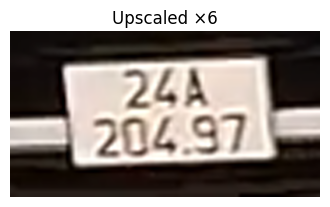

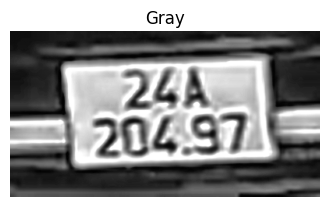

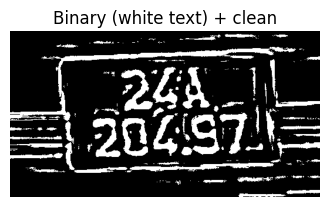

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Top line: 21A
Bottom line: 204.91
Plate: 21A 204.91


In [120]:
# ==== Simple LPR: gray -> binary -> white text (high contrast) -> OCR ====
from pathlib import Path
import cv2, numpy as np, re, matplotlib.pyplot as plt
import easyocr  # dùng EasyOCR cho gọn; đã ổn với ảnh nhỏ

# --- config ---
IMAGE_PATH = Path("image/image copy 3.png")  # đổi nếu cần
UPSCALE = 6           # phóng to vừa đủ
BLOCK = 21          # 21/25/31 cho adaptive
CVAL  = 10            # 2/3/5 tùy ảnh
DILATE =  4         # dãn 1 lần để chữ dày hơn

assert IMAGE_PATH.exists(), f"Không thấy ảnh: {IMAGE_PATH}"

def show(t, img, gray=False, size=(4,3)):
    plt.figure(figsize=size)
    if gray: plt.imshow(img, cmap="gray")
    else:    plt.imshow(img)
    plt.axis("off"); plt.title(t); plt.show()

# 1) đọc & upscale
bgr = cv2.imread(str(IMAGE_PATH))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
up  = cv2.resize(rgb, None, fx=UPSCALE, fy=UPSCALE, interpolation=cv2.INTER_CUBIC)
show(f"Upscaled ×{UPSCALE}", up)

# 2) gray + tăng tương phản + unsharp
gray = cv2.cvtColor(up, cv2.COLOR_RGB2GRAY)
cla  = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8)).apply(gray)
sharp= cv2.addWeighted(cla, 1.6, cv2.GaussianBlur(cla,(3,3),0), -0.6, 0)

# 3) nhị phân (adaptive) -> đảo để **chữ TRẮNG**, nền đen
bin_ = cv2.adaptiveThreshold(
    sharp, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, BLOCK, CVAL
)
# nếu trung bình là trắng (nền trắng) thì đảo lại cho chữ trắng nền đen
# (vì chữ gốc là đen trên trắng, sau THRESH_BINARY sẽ cho chữ đen → đảo)
if np.mean(bin_) > 127:
    white_text = 255 - bin_
else:
    # chữ đã trắng sẵn
    white_text = bin_.copy()

# 4) tăng độ "đậm" chữ & làm sạch viền
K = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1,1))
if DILATE > 0:
    white_text = cv2.dilate(white_text, K, iterations=DILATE)  # chữ sáng dày thêm
# bỏ nhiễu nhỏ bằng open nhẹ trên nền đen
clean_bin = cv2.morphologyEx(white_text, cv2.MORPH_OPEN, K, iterations=1)

show("Gray", sharp, True)
show("Binary (white text) + clean", clean_bin, True)

# 5) OCR với EasyOCR (thử cả 2 biến thể: gray_smooth và binary trắng chữ)
reader = easyocr.Reader(['en'])
def ocr_img(img, allow='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.'):
    res = reader.readtext(img, detail=1, allowlist=allow)
    toks = []
    for (box, text, conf) in res:
        text = re.sub(r'[^A-Za-z0-9.]','', text.upper())
        if text: toks.append((box, text, float(conf)))
    return toks

# biến thể 1: ảnh xám (thường tốt)
gray_rgb = cv2.cvtColor(sharp, cv2.COLOR_GRAY2RGB)
toks1 = ocr_img(gray_rgb)
# biến thể 2: ảnh nhị phân chữ trắng
bin_rgb  = cv2.cvtColor(clean_bin, cv2.COLOR_GRAY2RGB)
toks2 = ocr_img(bin_rgb)

# gộp & sắp theo trục y rồi x để tách 2 dòng
toks = toks1 if len(toks1) >= len(toks2) else toks2
items = []
for (box, text, conf) in toks:
    (x1,y1),(x2,y2),(x3,y3),(x4,y4) = box
    yc = (y1+y2+y3+y4)/4.0
    xc = (x1+x2+x3+x4)/4.0
    items.append((yc, xc, text, conf))

if not items:
    print("Không đọc được token nào — thử tăng UPSCALE hoặc chỉnh BLOCK/CVAL.")
else:
    H = gray.shape[0]
    items.sort(key=lambda t: t[0])
    ys = np.array([t[0] for t in items], np.float32)
    gaps = np.diff(ys)
    two_lines = (len(items) >= 2 and gaps.max() > 0.18*H)
    if two_lines:
        split = int(np.argmax(gaps)) + 1
        top = sorted(items[:split], key=lambda t: t[1])
        bot = sorted(items[split:], key=lambda t: t[1])
    else:
        top = items[:1]
        bot = sorted(items[1:], key=lambda t: t[1])

    # hậu xử lý theo format biển VN
    DIGIT_MAP = str.maketrans({'O':'0','Q':'0','D':'0','I':'1','L':'1','T':'1','Z':'2','S':'5','B':'8','G':'6'})
    LETTER_MAP= str.maketrans({'0':'O','1':'I','2':'Z','5':'S','6':'G','8':'B'})

    def join(ts): return ''.join(t[2] for t in ts)
    def top_fix(s):
        s = re.sub(r'[^A-Z0-9]','', s.upper())[:3]
        if len(s)==3:
            s = s[:2].translate(DIGIT_MAP) + s[2]
            s = s[:2] + s[2].translate(LETTER_MAP)
        m = re.search(r'\d{2}[A-Z]', s); return m.group(0) if m else s
    def bot_fix(s):
        s = s.replace('.','').translate(DIGIT_MAP)
        s = re.sub(r'[^0-9]','', s)[:5]
        return s[:3]+'.'+s[3:] if len(s)==5 else s

    top_text = top_fix(join(top))
    bot_text = bot_fix(join(bot))
    print("Top line:", top_text)
    print("Bottom line:", bot_text)
    print("Plate:", (top_text + " " + bot_text).strip())
